Goal: go from the HMF to the UVLF by parameterizing each step in the process \
Following Shen+23

In [141]:
import numpy as np
import zeus21
from classy import Class
import cosmo_calc
import importlib
from astropy import constants as c
from astropy import units as u
import eplots
from scipy.interpolate import interp1d
import hmf as halomassfunction
import emcee
import corner

In [3]:
z = 9

# HMF

In [4]:
# Trying Tinker HMF
# M_halo = np.logspace(9, 14, 100)
#params, HMFintclass = cosmo_calc.hmf_zeus(z = z, HMF_CHOICE='ST')
# hmf = HMFintclass.HMF_int(M_halo, z)
params = cosmo_calc.get_params()
my_hmf = halomassfunction.hmf.MassFunction(Mmin = 9, Mmax = 14, dlog10m = .05, hmf_model = 'Tinker10', z = z)
M_halo = my_hmf.m/params['h']
hmf = my_hmf.dndm*params['h']**4

Text(0.5, 1.0, 'HMF, $z=9$')

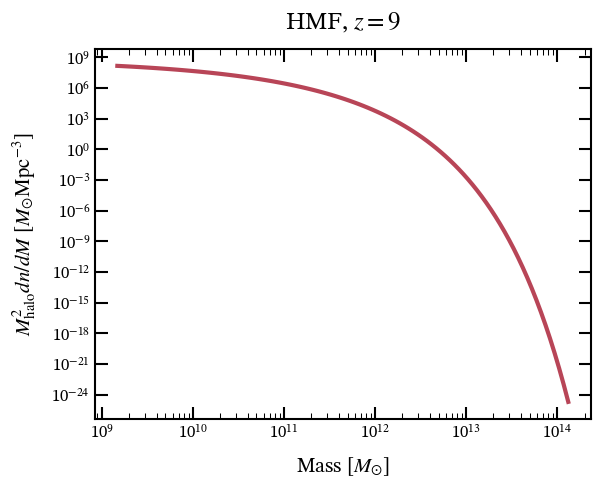

In [5]:
fig, ax = plt.subplots()
ax.loglog(M_halo, hmf*M_halo**2)
ax.set_ylabel(r'$M_{\rm{halo}}^2 dn/dM$ [$M_{\odot}\rm{Mpc}^{-3}$]')
ax.set_xlabel(r'Mass [$M_{\odot}$]')
ax.set_title(f'HMF, $z={z}$')

# Mass accretion

In [6]:
def calc_M_dot(M_h, params, z = 0):
    return 25.3*(M_h/1e12)**(1.1)*(1+(1.65*z))*np.sqrt((params['Omega_m']*(1+z)**3)+params['Omega_L'])

In [7]:
m_dots = calc_M_dot(M_halo, params, z)

Text(0.5, 1.0, 'Mass accretion rate')

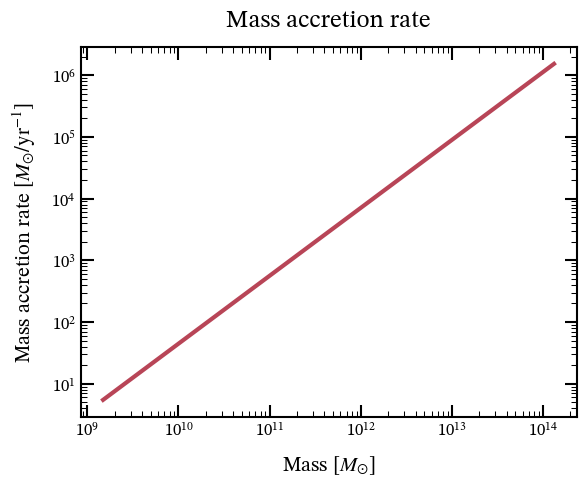

In [8]:
fig, ax = plt.subplots()
ax.loglog(M_halo, m_dots)
ax.set_xlabel(r'Mass [$M_{\odot}$]')
ax.set_ylabel(r'Mass accretion rate [$M_{\odot}/\rm{yr}^{-1}$]')
ax.set_title('Mass accretion rate')

In [9]:
def calc_SFE(M_h, eps_0 = 0.1, M_0 = 1e12, alpha = 0.6, beta = 0.5):
    return 2*eps_0/((M_h/M_0)**-alpha+(M_h/M_0)**beta)

In [10]:
SFE = calc_SFE(M_halo)

Text(0.5, 1.0, 'SFE')

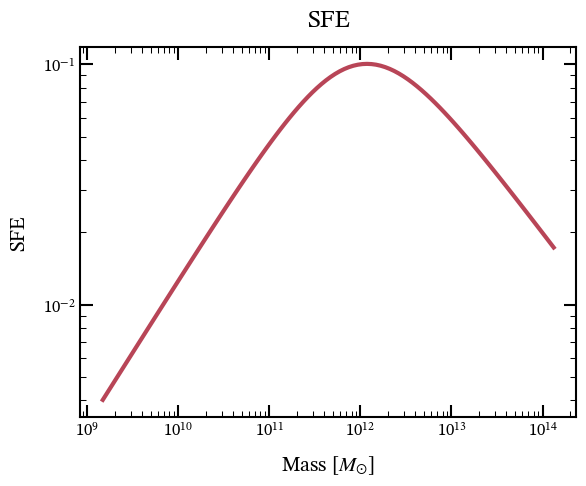

In [11]:
fig, ax = plt.subplots()
ax.loglog(M_halo, SFE)
ax.set_xlabel(r'Mass [$M_{\odot}$]')
ax.set_ylabel(r'SFE')
ax.set_title('SFE')

In [12]:
def calc_SFR(M_h, params, z=0):
    fb = params['Omega_b']/params['Omega_m']
    M_dot = calc_M_dot(M_h, params, z)
    eps_star = calc_SFE(M_h)
    return fb*M_dot*eps_star

In [13]:
sfrs = calc_SFR(M_halo, params, z)

Text(0.5, 1.0, 'SFR')

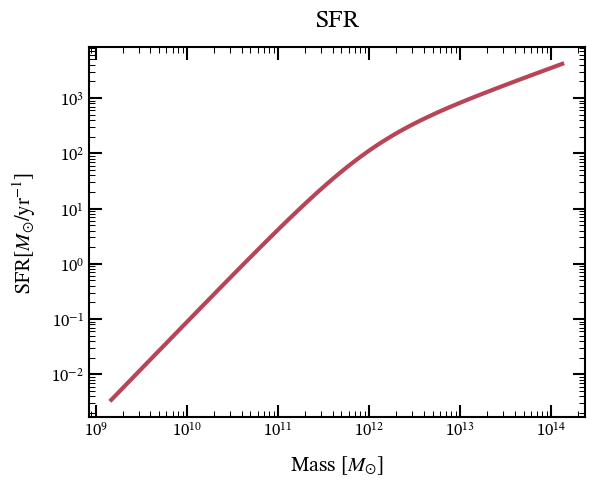

In [14]:
fig, ax = plt.subplots()
ax.loglog(M_halo, sfrs)
ax.set_xlabel(r'Mass [$M_{\odot}$]')
ax.set_ylabel(r'SFR[$M_{\odot}/\rm{yr}^{-1}$]')
ax.set_title('SFR')

In [15]:
def calc_L_UV(M_h, params, z=0, Kappa_UV = 1.15e-28):
    SFR = calc_SFR(M_h, params, z)
    return SFR/Kappa_UV

def calc_M_UV(M_h, params, z=0):
    L_UV = calc_L_UV(M_h, params, z)
    M_UV = 51.63-(2.5*np.log10(L_UV)) # Same as Zeus
    return M_UV

def M_to_L(M_UV):
    return 10**(0.4*(51.63-M_UV))

In [16]:
L_UV = calc_L_UV(M_halo, params, z)
M_UV = calc_M_UV(M_halo, params, z)

In [17]:
# Shen data for comparison
# curve_MUV = np.array([-16.01484019211786, -2.815453815043948,
# -17.350229363505903, -3.1980023281602312,
# -19.021853821204303, -3.871054662015942,
# -19.997693922074475, -4.39653801466181,
# -21.00686431468839, -5.137571346589897,
# -21.768960854741977, -5.950698690481298,
# -22.418814443679437, -6.83218206586089,
# -22.96754485653375, -7.843992421281851
# ]).reshape(-1, 2)

shen_curve = np.array([-15.997965648522188, -2.699480617612502,
-16.492167746810427, -2.9178288072472736,
-16.885291638815424, -3.0945765850296647,
-17.222296492196808, -3.260878590734152,
-17.57051934087012, -3.427197203389479,
-17.91882937603534, -3.6246040280159266,
-18.25583422941672, -3.790906033720414,
-18.750181638524804, -4.061067909973719,
-19.120985788601818, -4.279233423149259,
-19.401929727687524, -4.4558151314232575,
-19.795257054840302, -4.705102070471597,
-20.222354616524747, -4.99588977966728,
-20.750675695312275, -5.3800915873338795,
-21.132930337992967, -5.681175606049913,
-21.459007817722107, -5.951088378040629,
-21.86387282397047, -6.314382034600582,
-22.246418088290856, -6.719093426553684,
-22.583975122787642, -7.082287441408602,
-22.83167194629312, -7.403897651361978,
-23.056874654886805, -7.704749172766261,
-23.248394315440727, -7.99518813599432]).reshape(-1,2)
shen_phi_UV = shen_curve[:,1] # This is already in log space, so I won't have to take the log later
shen_M_UV = shen_curve[:,0]

In [18]:
def interpolate(x0, y0, x1):
    # Make sure the range you're interpolating is defined for both
    defined_range = np.where((x1 >= np.min(x0)) & (x1 <= np.max(x0)))[0] # This is the indices in x1 where x0 is defined. Use it to cut
    # x1 and y1 when you're plotting to make sure everything is consistent
    try: 
        interpolater = interp1d(x0, y0)
        return interpolater(x1[defined_range]), defined_range
    except: # If your x0 is strictly DECREASING, this will work by switching the order of everything
        interpolater  = interp1d(x0[::-1], y0[::-1])
        return interpolator(x1[defined_range])[::-1], defined_range

In [19]:
my_uvlf = np.log10(hmf*np.abs(np.gradient(M_halo, M_UV))) # Must take the absolute value of dM/dM_UV
my_uvlf_compare, def_range = interpolate(M_UV, my_uvlf, shen_M_UV)

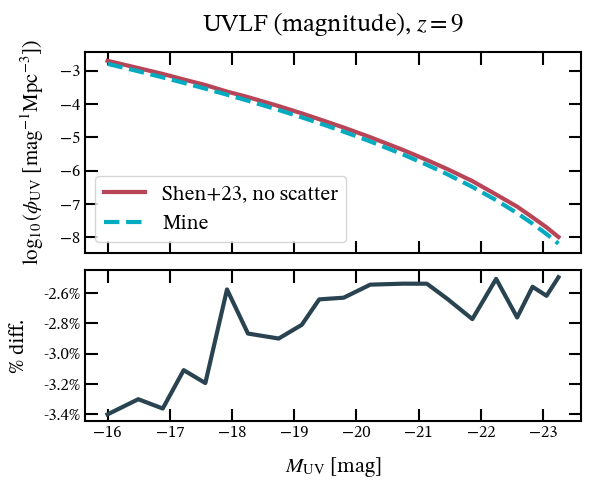

In [20]:
fig, axs = eplots.percent_diff_plot(shen_M_UV, shen_phi_UV, my_uvlf_compare, labels = ['Shen+23, no scatter', 'Mine'])

axs[0].invert_xaxis()
axs[1].set_xlabel(r'$M_{\rm{UV}}$ [mag]')
axs[0].set_ylabel(r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])')
axs[1].set_ylabel('% diff.')
axs[0].set_title(f'UVLF (magnitude), $z={z}$')
axs[0].legend()

#fig.savefig('/Users/eb35267/Desktop/figures/ongoing/UVLF_mag.png')

In [22]:
def calc_M_UV_dust(M_halo, params, z=0):
    """
    This makes galaxies fainter than ~18.5 brighter...
    """
    M_UV = calc_M_UV(M_halo, params, z)
    M_UV_obs = (M_UV - 6.35)/1.34
    M_UV_obs = np.where(M_UV_obs > M_UV, M_UV_obs, M_UV)

    return M_UV_obs

In [23]:
shen_with_dust = np.array([-15.990384615384615, -2.699481865284974,
-16.641025641025642, -2.9689119170984455,
-17.459935897435898, -3.373056994818653,
-18.536858974358974, -3.9119170984455955,
-19.17628205128205, -4.3160621761658025,
-19.849358974358974, -4.875647668393782,
-20.567307692307693, -5.601036269430051,
-21.060897435897438, -6.181347150259067,
-21.621794871794872, -7,
-22.16025641025641, -7.974093264248704]).reshape(-1, 2)
shen_phi_dust = shen_with_dust[:,1] # This is already in log space, so I won't have to take the log later
shen_M_UV_dust = shen_with_dust[:,0]

In [24]:
M_UV_dust = calc_M_UV_dust(M_halo, params, z)
my_uvlf_dust = np.log10(hmf*np.abs(np.gradient(M_halo, M_UV_dust))) # Must take the absolute value of dM/dM_UV
# my_uvlf_compare_dust = interpolate(M_UV_dust, my_uvlf_dust, shen_M_UV_dust)
shen_comp, def_range = interpolate(shen_M_UV_dust, shen_phi_dust, M_UV_dust)

Text(0.5, 1.0, 'UVLF, $z=9$')

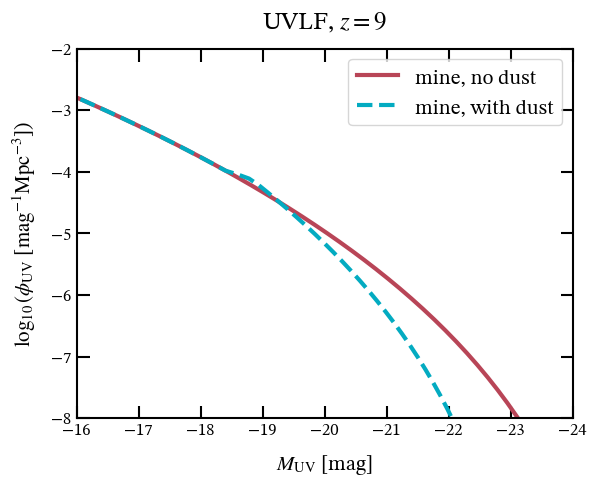

In [25]:
fig, ax = plt.subplots()
ax.plot(M_UV, my_uvlf, label = 'mine, no dust')
ax.plot(M_UV_dust, my_uvlf_dust, label = 'mine, with dust', linestyle = '--')
ax.invert_xaxis()
ax.legend()
ax.set_ylim(-8, -2)
ax.set_xlim(-16, -24)

ax.set_xlabel(r'$M_{\rm{UV}}$ [mag]')
ax.set_ylabel(r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])')
ax.set_title(f'UVLF, $z={z}$')

#fig.savefig('/Users/eb35267/Desktop/figures/ongoing/problems/UVLF_dust.png')

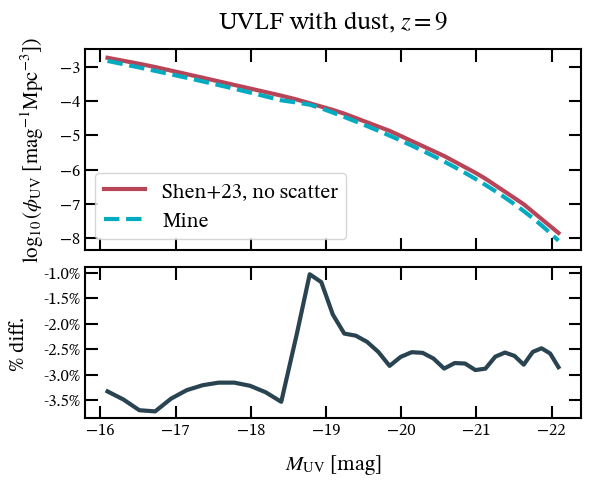

In [26]:
fig, axs = eplots.percent_diff_plot(M_UV_dust[def_range], shen_comp, my_uvlf_dust[def_range], labels = ['Shen+23, no scatter', 'Mine'])
axs[0].invert_xaxis()
axs[1].set_xlabel(r'$M_{\rm{UV}}$ [mag]')
axs[0].set_ylabel(r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])')
axs[1].set_ylabel('% diff.')
axs[0].set_title(f'UVLF with dust, $z={z}$')
axs[0].legend()

#fig.savefig('/Users/eb35267/Desktop/figures/ongoing/problems/UVLF_dust_comparison.png')

# MCMC

In [145]:
# Parameters are epsilon_0, M_0, alpha, beta
lowers = [0, 0, 0]
uppers = [1, 1, 1]

In [146]:
phot_z = np.array([-17.3, -2.87,
-18.3, -3.21,
-17.9, -3.70,
-18.2, -3.86,
-18.3, -3.48,
-18.9, -3.63,
-18.9, -3.79,
-18.8, -3.74,
-19.6, -4.03,
-20.1, -4.12,
-19.2, -4.63,
-19.0, -4.57,
-20.1, -4.43,
-20.0, -4.51,
-20.2, -4.90,
-20.3, -4.71,
-20.4, -5.00,
-20.8, -4.92,
-21.0, -5.01,
-21.0, -5.47,
-21.2, -5.32,
-21.8, -5.91,
-22.2, -5.21,
-23.2, -5.25,
-22.6, -6.95,
-23.5, -7.46
]).reshape(-1,2)
data_x, data_y = phot_z[:,0][np.argsort(phot_z[:,0])], phot_z[:,1][np.argsort(phot_z[:,0])] # order

In [147]:
class UVLF_MCMC:
    def __init__(self, lowers, uppers, z = 0, Mmin = 9, Mmax = 14, dlog10m = .05, hmf_model = 'Tinker10'):
        self.params = cosmo_calc.get_params()
        self.z = z
        my_hmf = halomassfunction.hmf.MassFunction(Mmin = Mmin, Mmax = Mmax, dlog10m = dlog10m, hmf_model = hmf_model, z = self.z)
        self.M_h = my_hmf.m/params['h']
        self.hmf = my_hmf.dndm*params['h']**4
        self.lowers = lowers
        self.uppers = uppers
        
    # Gaussian log-likelihood
    def log_likelihood(self, theta, x, y):
        """
        theta [1darr]: list of the current values of the parameters that need to be estimated
        x, y [1darr, 1darr]: the datapoints to fitt
        yerr [1darr]: error on the datapoints
        """
        model = self.UVLF_model(x, *theta)
        return -0.5 * np.sum((y - model)**2) # Usually there's error on the datapoints too but I'm ignoring that
        # Changed the square to be inside the parentheses
    
    # Log uniform prior
    def log_prior(self, theta):
        if all(lower < t < upper for t, lower, upper in zip(theta, self.lowers, self.uppers)):
            return 0.0  # log(1)
        return -np.inf  # log(0)
    
    # Combined log-posterior
    def log_probability(self, theta, x, y):
        lp = self.log_prior(theta)
        if not np.isfinite(lp):
            return -np.inf
        return lp + self.log_likelihood(theta, x, y)

    def interpolate(self, x0, y0, x1):
        # Make sure the range you're interpolating is defined for both
        defined_range = np.where((x1 >= np.min(x0)) & (x1 <= np.max(x0)))[0] # This is the indices in x1 where x0 is defined. Use it to cut
        # x1 and y1 when you're plotting to make sure everything is consistent
        try: 
            interpolater = interp1d(x0, y0)
            return interpolater(x1[defined_range]), defined_range
        except: # If your x0 is strictly DECREASING, this will work by switching the order of everything
            interpolater  = interp1d(x0[::-1], y0[::-1])
            return interpolator(x1[defined_range])[::-1], defined_range

    def UVLF_model(self, x, eps_0, alpha, beta, M_0 = 1e12):
        M_dot = self.calc_M_dot(self.M_h)
        SFE = self.calc_SFE(self.M_h, eps_0, M_0, alpha, beta)
        SFR = self.calc_SFR(self.M_h, M_dot)
        M_UV = self.calc_M_UV(SFR)
        M_UV_dust = self.calc_M_UV_dust(M_UV)
        uvlf = np.log10(self.hmf*np.abs(np.gradient(self.M_h, M_UV_dust)))
        uvlf_interp, defined_range = self.interpolate(M_UV_dust, uvlf, x)
        
        return uvlf_interp
        
    def calc_M_dot(self, x):
        return 25.3*(x/1e12)**(1.1)*(1+(1.65*self.z))*np.sqrt((self.params['Omega_m']*(1+z)**3)+self.params['Omega_L'])

    def calc_SFE(self, x, eps_0, M_0, alpha, beta):
        return 2*eps_0/((x/M_0)**-alpha+(x/M_0)**beta)

    def calc_SFR(self, x, M_dot):
        fb = params['Omega_b']/params['Omega_m']
        return fb*M_dot*SFE

    def calc_M_UV(self, SFR, Kappa_UV = 1.15e-28):
        L_UV = SFR/Kappa_UV
        M_UV = 51.63-(2.5*np.log10(L_UV))
        return M_UV

    def calc_M_UV_dust(self, M_UV):
        M_UV_obs = (M_UV - 6.35)/1.34
        M_UV_obs = np.where(M_UV_obs > M_UV, M_UV_obs, M_UV) # Make sure it doesn't boost the brightness of faint galaxies
    
        return M_UV_obs 

In [148]:
fiducial = np.array([0.1, 0.6, 0.5])
nwalkers = 30
ndim = len(fiducial)
start = fiducial + 1e-4*np.random.randn(nwalkers, ndim) # Start each of the walkers in a slightly different place
my_MCMC = UVLF_MCMC(lowers, uppers, z = 9)

sampler = emcee.EnsembleSampler(nwalkers, ndim, my_MCMC.log_probability, args=(data_x, data_y))
sampler.run_mcmc(start, 5000, progress=True)

You must install the tqdm library to use progress indicators with emcee


State([[0.34733716 0.08183716 0.43656575]
 [0.7915774  0.66610253 0.65473264]
 [0.23236043 0.10829305 0.6599744 ]
 [0.32042356 0.72733175 0.63333566]
 [0.11647249 0.96037618 0.46949641]
 [0.82699564 0.49684144 0.67394392]
 [0.60198684 0.42266881 0.1855067 ]
 [0.49680742 0.19151788 0.58997566]
 [0.03125355 0.51406188 0.17535205]
 [0.08653839 0.98262505 0.53031327]
 [0.0733876  0.13581901 0.34122191]
 [0.95208976 0.74972304 0.29509748]
 [0.16585054 0.2515384  0.34019871]
 [0.12345197 0.26384227 0.39363794]
 [0.02729421 0.26677327 0.62625341]
 [0.20804871 0.80607789 0.54480885]
 [0.48331288 0.52714132 0.13123338]
 [0.01307587 0.24479    0.0565749 ]
 [0.10007351 0.89972586 0.97031411]
 [0.34032382 0.71538675 0.66015366]
 [0.04523211 0.83719093 0.93207134]
 [0.18390852 0.62906378 0.46717966]
 [0.29559973 0.22642267 0.04321649]
 [0.76454243 0.63495398 0.84707906]
 [0.83241903 0.42022407 0.91934987]
 [0.09612722 0.32451694 0.85953005]
 [0.97840556 0.65599814 0.96018728]
 [0.0842577  0.2737158

Text(0.5, 0, 'step number')

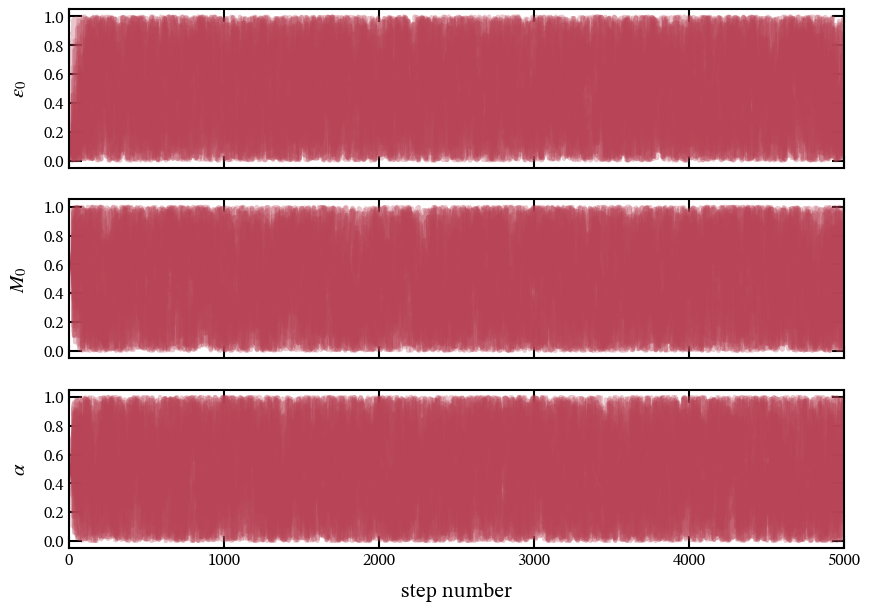

In [151]:
fig, axes = plt.subplots(len(lowers), figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = [r"$\epsilon_0$", r"$M_0$", r"$\alpha$", r"$\beta$"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], '#b84557', alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])

axes[-1].set_xlabel("step number")

In [152]:
flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)

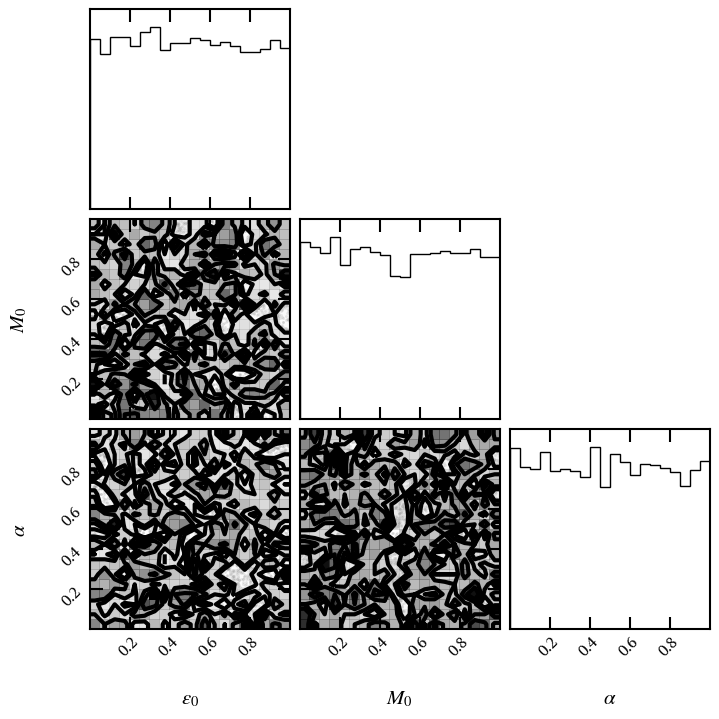

In [158]:
fig = corner.corner(flat_samples, labels=labels)

# fig.savefig('/Users/eb35267/Desktop/figures/ongoing/problems/MCMC.png')